## 1.模型的profile属性

In [ ]:
from langchain_core.messages import SystemMessage,HumanMessage,AIMessage
from langchain_ollama import ChatOllama
from openai import max_retries

llm = ChatOllama(
    model='deepseek-r1:8b',
    temperature=0.7

)

print(llm.profile) # 本地大模型是None


None


In [ ]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os

load_dotenv(override=True)
gemini_api_key = os.getenv("gemini_api_key")

llm = ChatOpenAI(
    model="gemini-3.1-flash-lite",
    api_key=gemini_api_key,
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)
print(llm.profile) # 输出为空

{}


## 模型初始化参数
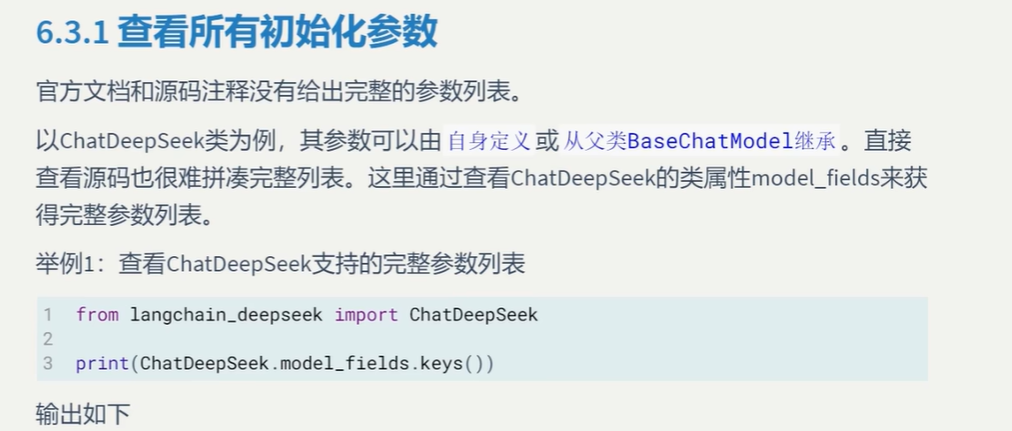

In [3]:
from langchain_deepseek import ChatDeepSeek

print(ChatDeepSeek.model_fields.keys())

dict_keys(['name', 'cache', 'verbose', 'callbacks', 'tags', 'metadata', 'custom_get_token_ids', 'rate_limiter', 'disable_streaming', 'output_version', 'profile', 'client', 'async_client', 'root_client', 'root_async_client', 'model_name', 'temperature', 'model_kwargs', 'openai_api_key', 'openai_api_base', 'openai_organization', 'openai_proxy', 'request_timeout', 'stream_usage', 'max_retries', 'presence_penalty', 'frequency_penalty', 'seed', 'logprobs', 'top_logprobs', 'logit_bias', 'streaming', 'n', 'top_p', 'max_tokens', 'reasoning_effort', 'reasoning', 'verbosity', 'tiktoken_model_name', 'default_headers', 'default_query', 'http_client', 'http_async_client', 'stop', 'extra_body', 'include_response_headers', 'disabled_params', 'context_management', 'include', 'service_tier', 'store', 'truncation', 'use_previous_response_id', 'use_responses_api', 'api_key', 'api_base'])


In [4]:
print(ChatOpenAI.model_fields.keys())

dict_keys(['name', 'cache', 'verbose', 'callbacks', 'tags', 'metadata', 'custom_get_token_ids', 'rate_limiter', 'disable_streaming', 'output_version', 'profile', 'client', 'async_client', 'root_client', 'root_async_client', 'model_name', 'temperature', 'model_kwargs', 'openai_api_key', 'openai_api_base', 'openai_organization', 'openai_proxy', 'request_timeout', 'stream_usage', 'max_retries', 'presence_penalty', 'frequency_penalty', 'seed', 'logprobs', 'top_logprobs', 'logit_bias', 'streaming', 'n', 'top_p', 'max_tokens', 'reasoning_effort', 'reasoning', 'verbosity', 'tiktoken_model_name', 'default_headers', 'default_query', 'http_client', 'http_async_client', 'stop', 'extra_body', 'include_response_headers', 'disabled_params', 'context_management', 'include', 'service_tier', 'store', 'truncation', 'use_previous_response_id', 'use_responses_api'])


## 使用init_chat_model的方式

In [5]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os


load_dotenv(override=True)
gemini_api_key=os.getenv("gemini_api_key")

# model = init_chat_model("openai:gpt-4o", temperature=0)
model = init_chat_model("google_genai:gemini-3.1-flash-lite",api_key=gemini_api_key, temperature=0)
print(model.model_fields.keys())

dict_keys(['name', 'cache', 'verbose', 'callbacks', 'tags', 'metadata', 'custom_get_token_ids', 'rate_limiter', 'disable_streaming', 'output_version', 'profile', 'google_api_key', 'credentials', 'vertexai', 'project', 'location', 'base_url', 'additional_headers', 'client_args', 'api_version', 'model', 'temperature', 'frequency_penalty', 'presence_penalty', 'top_p', 'top_k', 'max_output_tokens', 'n', 'max_retries', 'timeout', 'response_modalities', 'media_resolution', 'image_config', 'thinking_budget', 'include_thoughts', 'safety_settings', 'seed', 'labels', 'client', 'default_metadata', 'model_kwargs', 'streaming', 'convert_system_message_to_human', 'stop', 'response_mime_type', 'response_schema', 'reasoning_effort', 'thinking_config', 'cached_content'])


C:\Users\kenny\AppData\Local\Temp\ipykernel_14068\4151200947.py:11: PydanticDeprecatedSince211: Accessing the 'model_fields' attribute on the instance is deprecated. Instead, you should access this attribute from the model class. Deprecated in Pydantic V2.11 to be removed in V3.0.
  print(model.model_fields.keys())


## model_kwargs参数的使用
### 有一些参数在langchain框架中没有列出来，但是模型本身支持的就可以放到model_kwargs参数里面，不过有时候你指定的函数模型并没有识别出来，同样是不会调用的，
### 可能付费模型会好一点

In [ ]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
import rich


load_dotenv(override=True)
gemini_api_key=os.getenv("gemini_api_key")

# model = init_chat_model("openai:gpt-4o", temperature=0)
model = init_chat_model(
    "google_genai:gemini-3.1-flash-lite",
    model_kwargs={
        "tools":[
            {
                "type":"function",
                "function":{
                    "name":"get_weather",
                    "description":"Get weather of a location,the user should supply the location first.",
                    "parameters":{
                        "type":"object",
                        "properties":{
                            "location":{
                                "type":"string",
                                "description":"The City and state,e.g. San Francisco,CA",
                            }
                        },
                        "required":["location"]
                    }
                },
            }
        ]
    },
    api_key=gemini_api_key,
    temperature=0
    )

resp = model.invoke("你好，北京今天的天气如何？")
rich.print(resp) # 这个模型没有识别出我们指定的工具，因为，tool_calls=[],

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


AIMessage(
    content=[
        {
            'type': 'text',
            'text': '今天是2024年5月23日，星期四。\n\n北京今天的天气情况如下：\n*   **天气状况**：晴间多云。\n*   
**气温**：白天最高气温在 **32℃** 左右，夜间最低气温在 **17℃** 左右。\n*   **风力**：偏南风 2-3 级。\n*   
**空气质量**：良。\n\n**温馨提示**：\n今天白天紫外线较强，气温较高，体感会比较热，建议外出时注意做好防晒措施，并适
当补充水分。早晚温差较大，如果早出晚归，建议带一件薄外套。\n\n*注：天气信息实时变化，建议您出门前查看手机自带的天气
应用以获取最新预报。*',
            'extras': {
                'signature': 
'EnEKbwERTTIP+KPLlJiKhcO47CD3FR/swxoBXD1LgfZCegGQnHck32LF2UR1e+uDxGm1q31qR3X+fw8tcXBVNUQGVrpf+R6I7X+Gt/r+/Cwc19IlLa
+CyRYSjGvBcZAvESeyQqg5xY40Sk1GjMFFVXZNng=='
            }
        }
    ],
    additional_kwargs={},
    response_metadata={
        'finish_reason': 'STOP',
        'model_name': 'gemini-3.1-flash-lite',
        'safety_ratings': [],
        'model_provider': 'google_genai'
    },
    id='lc_run--01a08232-6c3d-7cf1-96e8-fbd4156f46c8-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 9,
        'output_tokens': 181,
        'total_tokens': 190,
        'input_token_details': {'cache_read': 0}
    }
)

### 本地大模型可以使用工具吗？

In [ ]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model='deepseek-r1:8b',
    model_kwargs={
            "tools":[
                {
                    "type":"function",
                    "function":{
                        "name":"get_weather",
                        "description":"Get weather of a location,the user should supply the location first.",
                        "parameters":{
                            "type":"object",
                            "properties":{
                                "location":{
                                    "type":"string",
                                    "description":"The City and state,e.g. San Francisco,CA",
                                }
                            },
                            "required":["location"]
                        }
                    },
                }
            ]
        },
)

question = "你好，北京2023年10月3号的天气如何？"

result = llm.invoke(question)
print(result.content) # 本地的deepseek大模型无法提供天气信息


根据我的知识库，2023年10月3日的天气信息可能无法直接提供，因为这涉及到具体的天气预报数据，而我的功能主要集中在处理语言和信息查询上，不包括预测特定日期的天气。不过，如果您需要了解北京的天气，我可以建议您参考专业的天气预报服务，如中国气象局或相关天气应用，以获取最准确和最新的信息。


In [32]:
import os
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage


llm = init_chat_model(
    # model="openai/gpt-oss-120b",  # 指定具体的 Groq 模型名称
    model="qwen/qwen3.6-27b",  # 指定具体的 Groq 模型名称
    model_kwargs={
                "tools":[
                    {
                        "type":"function",
                        "function":{
                            "name":"get_weather",
                            "description":"Get weather of a location,the user should supply the location first.",
                            "parameters":{
                                "type":"object",
                                "properties":{
                                    "location":{
                                        "type":"string",
                                        "description":"The City and state,e.g. San Francisco,CA",
                                    }
                                },
                                "required":["location"]
                            }
                        },
                    }
                ]
            },
    model_provider="groq",    # 明确指定提供商为 groq
    temperature=0.7
)

# 调用模型
messages = [
    HumanMessage(content="今天北京会下雨吗"),
    # HumanMessage(content="什么水果对肾好？"),
]

response = llm.invoke(messages)

# 打印输出结果
response.pretty_print()

RateLimitError: Error code: 429 - {'error': {'message': "Request too large for model `qwen/qwen3.6-27b` in organization `org_01m1hgqe33ead85jq0g6w3ybrp` service tier `on_demand` on output tokens per minute (OTPM): Limit 1000, Requested 2048. The request's expected output tokens exceed the enforced limit; reduce max_tokens (or the request's expected output) and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing", 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [35]:
import os
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage


llm = init_chat_model(
    model="openai/gpt-oss-120b",  # 指定具体的 Groq 模型名称
    # model="groq/compound-mini",  # 指定具体的 Groq 模型名称，这个模型不支持工具调用
    # model="groq/compound",  # 指定具体的 Groq 模型名称，这个模型不支持工具调用
    model_kwargs={
                "tools":[
                    {
                        "type":"function",
                        "function":{
                            "name":"get_weather",
                            "description":"Get weather of a location,the user should supply the location first.",
                            "parameters":{
                                "type":"object",
                                "properties":{
                                    "location":{
                                        "type":"string",
                                        "description":"The City and state,e.g. San Francisco,CA",
                                    }
                                },
                                "required":["location"]
                            }
                        },
                    }
                ]
            },
    model_provider="groq",    # 明确指定提供商为 groq
    temperature=0.7
)

# 调用模型
messages = [
    HumanMessage(content="今天北京会下雨吗"),
    # HumanMessage(content="什么水果对肾好？"),
]

response = llm.invoke(messages)

# 打印输出结果
response.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  get_weather (fc_12fc94a2-b7c7-43b8-89b8-0a98fd0363a6)
 Call ID: fc_12fc94a2-b7c7-43b8-89b8-0a98fd0363a6
  Args:
    location: Beijing, China


## extra_body的使用

In [36]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model='deepseek-r1:8b',
    extra_body={
        "thinking":{"type":"enabled"}
    }
)

question = "女人法语怎么说"

result = llm.invoke(question)
print(result.content)


“女人”用法语可以说：

*   **单数形式**：**Femme**
    *   发音：/fɑ̃m/ (范)
*   **复数形式**：**Femmes**
    *   发音：/fɑ̃mɛs/ (范·mez)

你需要根据具体的语境来选择使用单数还是复数。如果你指的是“一个女人”，用 **femme**；如果你指的是“一些女人”或“女性们”，用 **femmes**。

**注意**：在现代法语中，有时也会使用更中性的 **personne** (人)，但这个词通常指代任何人，不分性别。另外，**une femme** 通常指一个女性，而不是泛指所有女人。


## config参数的使用

In [37]:
def mycb():
    print("this is my call ball")

In [ ]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model='deepseek-r1:8b',
    extra_body={
        "thinking":{"type":"enabled"}
    }
)

question = "女人法语怎么说"

result = llm.invoke(
    question,
    config={
        "run_name":"my test",
        "tags":["test","development"],
        "metadata":{"user_id":'124'},
        # 暂时不使用callback参数，等到用到的时候才添加
        "configurable":{
            "model":"deepseek-reasoner",
            "temprature":0.7,
             "max_tokens":200
        }
    }

)
print(result.content)


“女人”在法语中通常翻译为 **“une femme”**。

**解释：**
- **“Femme”** 是法语中表示“女人”的单词，它是阴性名词。
- 在法语中，阴性名词前通常需要冠词 **“la”**（相当于英语中的 "the" 的阴性形式），因此完整的说法是 **“une femme”**（不定冠词形式，表示“一个女人”）。

**注意：**
- 法语中名词有性别之分，因此“女人”不能简单地翻译为“une femme”并加上阳性冠词。
- 另外，法语中也使用 **“une femelle”** 来表示“女人”或“雌性动物”，但在现代法语中，“femme”更为常用，而“femelle”则较少使用，通常用于动物或某些特定语境。

**例如：**
- “她是一个女人。” 法语：**“Elle est une femme.”**
- “我认识一个女人。” 法语：**“Je connais une femme.”**

希望这能帮到你！
